# 1. Configuración Experimental y Reproducibilidad

En cualquier experimento de Deep Learning o Machine Leraning, la reproducibilidad es un requisito crítico. Debido a la naturaleza estocástica de los algoritmos de optimización y de las operaciones ejecutadas sobre CPU (o GPU cuando sea el caso), pequeños cambios pueden producir diferencias significativas en los resultados finales del entrenamiento.

Por esta razón, antes de comenzar la construcción de modelos de clasificación binaria para galaxias con y sin anillo interno, definimos una configuración experimental controlada que permita:

- Garantizar reproducibilidad entre ejecuciones.
- Controlar las semillas aleatorias (`random`, `numpy`, `torch`).
- Configurar correctamente CPU/GPU.
- Habilitar operaciones determinísticas en PyTorch.
- Centralizar hiperparámetros globales del experimento.
- Definir rutas base del proyecto.
- Registrar automáticamente el dispositivo de entrenamiento disponible.

Esta sección constituye la base del notebook y debe ejecutarse antes de cualquier etapa de ingesta, entrenamiento o evaluación.

Además, se establece una estructura de configuración unificada que facilitará posteriormente:
- entrenamiento de múltiples arquitecturas,
- comparación experimental,
- validación cruzada,
- logging de métricas,
- y versionamiento de modelos.

La reproducibilidad es especialmente importante en este proyecto debido al uso de:
- Transfer Learning,
- Data Augmentation estocástico,
- Inicialización aleatoria de capas fully connected,
- y entrenamiento sobre GPU CUDA.

**LIBRERÍAS**

In [1]:
import os
import random
from pathlib import Path
import numpy as np
import pandas as pd
import torch
from matplotlib import pyplot as plt
import seaborn as sns

**SEMILLA ALEATORIA**

In [2]:
def set_global_seed(seed: int = 42) -> None:
    """
    Fija semillas globales para garantizar reproducibilidad.
    """

    random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # Operaciones determinísticas en CUDA
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # Determinismo adicional
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"✅ Semilla global configurada en: {seed}")

In [3]:
GLOBAL_SEED = 13

In [4]:
# Ejecutar configuración
set_global_seed(GLOBAL_SEED)

✅ Semilla global configurada en: 13


**CONFIGUCARIÓN DEL DISPOSITIVO**

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"🚀 Dispositivo disponible: {DEVICE}")

if torch.cuda.is_available():
    print(f"🖥️ GPU: {torch.cuda.get_device_name(0)}")
    print(f"🔥 CUDA Version: {torch.version.cuda}")

🚀 Dispositivo disponible: cpu


**DIRECTORIOS DE TRABAJO Y DATOS**

In [6]:
PROJECT_ROOT = Path("../../RingGalaxiesAnalysis").resolve()

DATA_DIR = PROJECT_ROOT / "data"
RAW_DATA_DIR = DATA_DIR / "raw"

CATALOGS_DIR = RAW_DATA_DIR / "catalogs"
FITS_DIR = RAW_DATA_DIR / "legacy_fits_files"

CATALOG_PATH = CATALOGS_DIR / "classification_dataset.csv"
print(f"📁 Directorio del proyecto: {PROJECT_ROOT}")
print(f"📁 Directorio de datos: {DATA_DIR}")
print(f"📁 Directorio de datos crudos: {RAW_DATA_DIR}")
print(f"📁 Directorio de catálogos: {CATALOGS_DIR}")
print(f"📁 Directorio de archivos FITS: {FITS_DIR}")
print(f"📁 Ruta del catálogo: {CATALOG_PATH}")

📁 Directorio del proyecto: /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis
📁 Directorio de datos: /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/data
📁 Directorio de datos crudos: /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/data/raw
📁 Directorio de catálogos: /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/data/raw/catalogs
📁 Directorio de archivos FITS: /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/data/raw/legacy_fits_files
📁 Ruta del catálogo: /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/data/raw/catalogs/classification_dataset.csv


**HIPERPARÁMETROS GLOBALES**

In [7]:
CONFIG = {
    # Datos
    "image_size": (256, 256),
    "num_channels": 3,
    "num_classes": 2,

    # Entrenamiento
    "batch_size": 32,
    "learning_rate": 1e-4,
    "weight_decay": 1e-5,
    "epochs": 10,

    # DataLoader
    "num_workers": 4,
    "pin_memory": True,

    # Reproducibilidad
    "seed": GLOBAL_SEED,

    # Transfer Learning
    "freeze_backbone": True
}

**VALIDACIÓN DE ARCHIVOS**

In [8]:
assert CATALOG_PATH.exists(), (
    f"No se encontró el catálogo: {CATALOG_PATH}"
)

assert FITS_DIR.exists(), (
    f"No se encontró el directorio FITS: {FITS_DIR}"
)

print("✅ Estructura de datos validada correctamente")

✅ Estructura de datos validada correctamente


**RESUMEN EXPERIMENTAL**

In [9]:
print("\n================ CONFIGURACIÓN EXPERIMENTAL ================")

for key, value in CONFIG.items():
    print(f"{key}: {value}")

print("============================================================")


================ CONFIGURACIÓN EXPERIMENTAL ================
image_size: (256, 256)
num_channels: 3
num_classes: 2
batch_size: 32
learning_rate: 0.0001
weight_decay: 1e-05
epochs: 10
num_workers: 4
pin_memory: True
seed: 13
freeze_backbone: True


# 2. Carga y Exploración del Dataset

Antes de entrenar cualquier arquitectura de Deep Learning, es fundamental comprender la composición del dataset y validar que la distribución de clases sea consistente con el problema científico que se desea resolver.

En este proyecto trabajamos con un problema de clasificación binaria:

- `label = 1` → galaxias con anillo interno.
- `label = 0` → galaxias sin anillo interno.

El catálogo consolidado generado durante la etapa de Exploratory Data Analysis (EDA) contiene:
- identificador único de galaxia (`name`),
- coordenadas astronómicas,
- corrimiento al rojo (`nsa_z`),
- y la etiqueta binaria objetivo (`label`).

## 2.1 Carga del catálogo

Se carga el archivo:
`classification_dataset.csv`

y se validan:
- dimensiones del dataset,
- tipos de datos,
- presencia de valores nulos,
- y distribución preliminar de clases.

In [10]:
df = pd.read_csv(CATALOG_PATH)
df.drop(columns=["source"], inplace=True)
print("✅ Catálogo cargado correctamente\n")
print(f"📊 Número total de registros en el catálogo: {df.shape[0]:,}")

✅ Catálogo cargado correctamente

📊 Número total de registros en el catálogo: 8,408


In [11]:
report_df = pd.read_csv("../data/processed/dataset_validation_report.csv")
print("✅ Reporte de validación cargado correctamente\n")

✅ Reporte de validación cargado correctamente



In [12]:
print(f"De acuerdo al reporte de validación, hay {report_df[report_df['complete'] == False].shape[0]:,} registros corruptos o incompletos que fueron excluidos del análisis")

De acuerdo al reporte de validación, hay 24 registros corruptos o incompletos que fueron excluidos del análisis


In [13]:
print("Eliminando registros corruptos del catálogo...")
invalid_ids = report_df[report_df["complete"] == False]["name"].tolist()
df = df[~df["name"].isin(invalid_ids)].reset_index(drop=True)
print(f"✅ Catálogo limpio. Registros restantes: {df.shape[0]:,}")

Eliminando registros corruptos del catálogo...
✅ Catálogo limpio. Registros restantes: 8,384


In [14]:
print("===================================================")
print("DIMENSIONES DEL DATASET")
print("===================================================")

print(f"Filas:    {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")

print("\n===================================================")
print("COLUMNAS")
print("===================================================")

display(df.head())

print("\n===================================================")
print("TIPOS DE DATOS")
print("===================================================")

print(df.dtypes)

print("\n===================================================")
print("VALORES NULOS")
print("===================================================")

print(df.isnull().sum())


DIMENSIONES DEL DATASET
Filas:    8384
Columnas: 6

COLUMNAS


,name,objra,objdec,nsa_z,anillos,label
0,1237648721210769659,134.44717,-0.199973,0.028206,0.0,0
1,1237648705657307354,198.23356,0.941188,0.048037,0.0,0
2,1237648705120895059,199.29492,0.527571,0.024114,0.0,0
3,1237648720150724863,165.74061,-0.962095,0.033483,0.0,0
4,1237649919509594232,31.37202,13.251016,0.024694,0.0,0



TIPOS DE DATOS
name           str
objra      float64
objdec     float64
nsa_z      float64
anillos    float64
label        int64
dtype: object

VALORES NULOS
name       0
objra      0
objdec     0
nsa_z      0
anillos    0
label      0
dtype: int64


## 2.2 Distribución de clases

Posteriormente analizamos la distribución de galaxias con y sin anillo interno mediante visualización estadística.

Este análisis es especialmente importante porque un posible desbalance de clases puede afectar significativamente:
- el proceso de entrenamiento,
- la convergencia del modelo,
- y la interpretación de métricas.

In [15]:
class_counts = df["label"].value_counts().sort_index()

num_label_0 = class_counts.get(0, 0)
num_label_1 = class_counts.get(1, 0)

total_samples = len(df)

pct_label_0 = (num_label_0 / total_samples) * 100
pct_label_1 = (num_label_1 / total_samples) * 100

print("\n===================================================")
print("DISTRIBUCIÓN DE CLASES")
print("===================================================")

print(f"Label 0 (Sin anillo): {num_label_0} ({pct_label_0:.2f}%)")
print(f"Label 1 (Con anillo): {num_label_1} ({pct_label_1:.2f}%)")


DISTRIBUCIÓN DE CLASES
Label 0 (Sin anillo): 6642 (79.22%)
Label 1 (Con anillo): 1742 (20.78%)


/tmp/ipykernel_10708/3716382674.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([


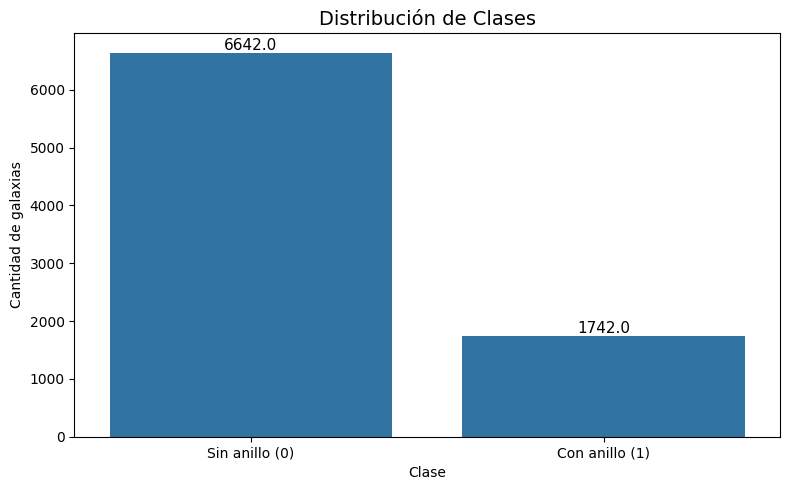

In [16]:
# VISUALIZACIÓN
plt.figure(figsize=(8, 5))

ax = sns.countplot(
    data=df,
    x="label"
)

ax.set_title("Distribución de Clases", fontsize=14)
ax.set_xlabel("Clase")
ax.set_ylabel("Cantidad de galaxias")

ax.set_xticklabels([
    "Sin anillo (0)",
    "Con anillo (1)"
])

# Mostrar cantidades sobre las barras
for p in ax.patches:
    height = p.get_height()
    ax.annotate(
        f"{height}",
        (p.get_x() + p.get_width() / 2., height),
        ha='center',
        va='bottom',
        fontsize=11
    )

plt.tight_layout()
plt.show()

In [17]:
# RATIO DE DESBALANCE
imbalance_ratio = max(num_label_0, num_label_1) / min(num_label_0, num_label_1)

print("\n===================================================")
print("ANÁLISIS DE DESBALANCE")
print("===================================================")

print(f"Imbalance Ratio: {imbalance_ratio:.2f}")

if imbalance_ratio < 1.5:
    print("✅ Dataset relativamente balanceado")
elif imbalance_ratio < 3:
    print("⚠️ Dataset moderadamente desbalanceado")
else:
    print("🚨 Dataset severamente desbalanceado")


ANÁLISIS DE DESBALANCE
Imbalance Ratio: 3.81
🚨 Dataset severamente desbalanceado


## 2.3 Análisis de métricas y desbalance

### Accuracy como métrica inicial

La métrica más intuitiva para clasificación binaria es:

$$
Accuracy = \frac{TP + TN}{TP + TN + FP + FN}
$$

donde:
- TP → True Positives
- TN → True Negatives
- FP → False Positives
- FN → False Negatives

Accuracy representa el porcentaje total de predicciones correctas.

Sin embargo, en problemas de calsifiación binaria con distribuciones desbalanceadas, esta métrica puede resultar engañosa.

### Problema de desbalance de clases

Si una clase domina el dataset, un modelo podría aprender a predecir únicamente la clase mayoritaria y aun así obtener un Accuracy elevado.

Ejemplo:
- 90% galaxias sin anillo
- 10% galaxias con anillo

Un modelo que siempre prediga "sin anillo" alcanzaría:
- Accuracy = 90%
- pero Recall = 0% para la clase minoritaria.

### Implicaciones sobre evaluación del modelo

Debido a esto, Accuracy no será suficiente para evaluar el desempeño real del clasificador.

Debemos complementar el análisis con métricas robustas al desbalance:

| Métrica | Justificación |
|---|---|
| Precision | Evalúa cuántas galaxias detectadas como anillo realmente poseen anillo |
| Recall (Sensitivity) | Evalúa cuántas galaxias con anillo fueron correctamente detectadas |
| F1-Score | Balance entre Precision y Recall |
| ROC-AUC | Capacidad discriminativa independiente del umbral |
| Confusion Matrix | Interpretabilidad detallada de errores |



## 2.4 Conclusiones del análisis exploratorio

El análisis de distribución de clases evidencia que el dataset presenta un desbalance severo entre galaxias con y sin anillo interno.

La composición observada es:

| Clase | Cantidad | Proporción |
|---|---|---|
| Sin anillo (`label = 0`) | 6660 | 79.21% |
| Con anillo (`label = 1`) | 1748 | 20.79% |

Además, el dataset presenta un:

$$
Imbalance\ Ratio = 3.81
$$

lo que indica que la clase mayoritaria contiene aproximadamente 3.8 veces más ejemplos que la clase minoritaria.

### Implicaciones científicas y computacionales

Este resultado tiene consecuencias importantes sobre el entrenamiento y evaluación de modelos de Deep Learning:

#### 1. Riesgo de sesgo hacia la clase mayoritaria

Sin mecanismos correctivos, el modelo tenderá naturalmente a favorecer la predicción de galaxias sin anillo, ya que esta estrategia minimiza la pérdida global durante el entrenamiento.

En consecuencia:
- el modelo podría alcanzar un Accuracy aparentemente elevado,
- pero presentar bajo desempeño detectando galaxias con anillo interno,
- que representan precisamente la clase de mayor interés científico.

#### 2. Accuracy deja de ser suficiente

Debido al desbalance severo:
- Accuracy pierde capacidad descriptiva,
- y puede inducir interpretaciones erróneas del desempeño real del clasificador.

Por esta razón, el proyecto debe priorizar métricas robustas al desbalance, especialmente:
- Recall,
- F1-Score,
- ROC-AUC,
- y matrices de confusión.

#### 3. Importancia del Recall

Desde una perspectiva científica, minimizar falsos negativos es especialmente importante.

Un falso negativo corresponde a una galaxia con anillo interno que el modelo clasifica incorrectamente como galaxia sin anillo.

Esto implica perder objetos astronómicos potencialmente relevantes para estudios morfológicos y evolutivos de galaxias.

Por ello, el Recall de la clase positiva (`label = 1`) será una métrica crítica durante la validación experimental.

### Estrategias propuestas para mitigar el desbalance

A partir de este análisis, el pipeline experimental deberá considerar técnicas específicas para reducir el impacto del desbalance:

| Estrategia | Objetivo |
|---|---|
| Weighted Loss Function | Penalizar más los errores sobre la clase minoritaria |
| Oversampling | Incrementar representación de galaxias con anillo |
| Data Augmentation | Generar mayor diversidad morfológica |
| Stratified Split | Mantener proporciones de clase en train/validation/test |
| F1-Score Monitoring | Optimizar equilibrio entre precisión y sensibilidad |

### Decisión metodológica

Considerando los resultados obtenidos, el entrenamiento de modelos de Transfer Learning en este proyecto se diseñará bajo un enfoque de clasificación desbalanceada, priorizando:
- sensibilidad sobre la clase minoritaria,
- estabilidad de generalización,
- y robustez científica de las métricas de evaluación.

# 3. Algoritmo baseline

## 3.1 Research sobre algoritmos de Deep Learning preentrenados para clasificación de galaxias

La clasificación morfológica de galaxias constituye uno de los problemas más relevantes dentro de la astronomía computacional moderna. Detectar automáticamente estructuras como:
- brazos espirales,
- barras,
- fusiones,
- y anillos internos,

requiere modelos capaces de aprender patrones espaciales complejos a partir de imágenes astronómicas de alta dimensionalidad.

En este contexto, entrenar redes neuronales profundas desde cero suele ser costoso debido a:
- limitaciones computacionales,
- tamaño moderado de datasets astronómicos etiquetados,
- y riesgo elevado de overfitting.

Por esta razón, una de las estrategias más utilizadas actualmente es el uso de **Transfer Learning**.

### Transfer Learning basado en ImageNet

Modelos como:
- ResNet,
- DenseNet,
- EfficientNet,
- VGG,
- Inception,

han sido entrenados sobre ImageNet, un dataset con millones de imágenes naturales.

Durante este entrenamiento, las primeras capas convolucionales aprenden representaciones visuales generales como:
- bordes,
- gradientes,
- texturas,
- formas,
- simetrías,
- y patrones espaciales.

Estas representaciones son relativamente universales y pueden reutilizarse exitosamente en otros dominios visuales, incluyendo astronomía.

En clasificación galáctica, esto resulta útil porque las galaxias también contienen:
- estructuras radiales,
- patrones circulares,
- regiones de alta luminosidad,
- discontinuidades,
- y formas geométricas complejas.

Por ello, la propuesta de usar modelos preentrenados en ImageNet tiene sentido respecto a este proyecto

**Limitaciones del Transfer Learning desde ImageNet**

Aunque el enfoque basado en ImageNet ha demostrado ser útil, presenta limitaciones importantes derivadas del fenómeno conocido como ***Domain Shift***

Domain Shift ocurre cuando el dominio sobre el cual un modelo fue entrenado difiere estadísticamente del dominio objetivo.

En este caso:
- ImageNet contiene imágenes naturales RGB,
- mientras que nuestro problema utiliza imágenes astronómicas FITS multibanda (`g`, `r`, `z`).

Las diferencias son significativas:

| ImageNet | Astronomía |
|---|---|
| Objetos naturales | Objetos astronómicos |
| Texturas cotidianas | Distribuciones fotométricas |
| RGB estándar | Bandas espectrales |
| Alto contraste | Bajo SNR frecuente |
| Escenas complejas | Patrones morfológicos difusos |

Además:
- galaxias presentan escalas físicas distintas,
- existe ruido instrumental,
- efectos observacionales,
- dispersión fotométrica,
- y patrones extremadamente sutiles.

Esto implica que:
- no todas las features aprendidas en ImageNet son óptimas para astronomía,
- y parte del conocimiento transferido puede ser irrelevante o incluso perjudicial.

Debido a estas limitaciones, surge la necesidad de "crear" modelos entrenados directamente sobre imágenes de galaxias.

Entre todos los proyectos existentes, uno de los más importantes es Galaxy Zoo.

Galaxy Zoo es un proyecto de *citizen science* iniciado en 2007 cuyo objetivo fue clasificar morfológicamente galaxias provenientes del Sloan Digital Sky Survey (SDSS).

Miles de voluntarios humanos participaron clasificando:
- galaxias espirales,
- elípticas,
- mergers,
- barras,
- anillos,
- irregularidades,
- y otras propiedades morfológicas.

El proyecto logró construir uno de los datasets astronómicos etiquetados más grandes de la historia:
- más de 1 millón de galaxias,
- y decenas de millones de clasificaciones humanas.

Galaxy Zoo se convirtió en una referencia fundamental para Machine Learning astronómico porque permitió entrenar modelos especializados directamente sobre morfologías galácticas reales.

En términos prácticos Galaxy Zoo puede considerarse el equivalente astronómico de ImageNet para clasificación de galaxias.

La principal ventaja es que:
- el dominio fuente y el dominio objetivo son mucho más similares,
- reduciendo significativamente el problema de Domain Shift.

A partir de Galaxy Zoo surgieron múltiples trabajos basados en:
- CNNs profundas,
- Bayesian CNNs,
- Active Learning,
- y Transfer Learning astronómico.

Los enfoques más relevantes incluyen:

| Modelo | Característica principal |
|---|---|
| Galaxy Zoo CNNs | Clasificación morfológica supervisada |
| Bayesian CNNs | Modelado de incertidumbre astronómica |
| Zoobot | Clasificación automática moderna basada en CNNs |
| Deep Transfer Learning astronómico | Fine-tuning sobre galaxias reales |

### Galaxy Zoo CNNs

Los primeros modelos Deep Learning derivados de Galaxy Zoo utilizaron redes convolucionales profundas entrenadas directamente sobre imágenes SDSS.

Estos modelos aprendieron:
- patrones morfológicos galácticos,
- simetrías,
- estructuras espirales,
- y características fotométricas complejas.

Galaxy Zoo CNNs son altamente relevantes porque:
- el problema es morfológicamente similar,
- trabajan sobre galaxias reales,
- y las features aprendidas son astronómicamente significativas.

Esto podría mejorar:
- detección de anillos internos,
- sensibilidad sobre estructuras débiles,
- y generalización científica.

Acá enunciamos algunas ventajas:

| Ventaja | Impacto |
|---|---|
| Menor Domain Shift | Mejor transferencia |
| Features astronómicas reales | Mayor relevancia científica |
| Entrenamiento sobre galaxias | Compatibilidad morfológica |
| Alta validación científica | Robustez metodológica |

Acá enunciamos algunas limitaciones:

- Menor disponibilidad pública de pesos.
- Ecosistema menos estandarizado que ImageNet.
- Mayor dificultad de implementación. **IMPORTANTE**

### ResNet + Transfer Learning ImageNet

ResNet sigue siendo una de las arquitecturas baseline más utilizadas en astronomía computacional.

Gracias a las conexiones residuales:
- el entrenamiento es estable,
- la convergencia es robusta,
- y el fine-tuning resulta relativamente sencillo.

Aunque existe Domain Shift, ResNet ofrece:
- excelente capacidad de extracción espacial,
- gran madurez experimental,
- y amplia integración con PyTorch.

Además:
- funciona muy bien en datasets medianos,
- y constituye un baseline sólido para comparación científica.

Acá enunciamos algunas de las ventajas:

| Ventaja | Impacto |
|---|---|
| Implementación simple | Experimentación rápida |
| Pesos ampliamente disponibles | Reproducibilidad |
| Excelente estabilidad | Robustez experimental |
| Buen desempeño en visión | Baseline fuerte |

Acá enunciamos algunas de las limitaciones:

- Features no especializadas para astronomía.
- Dependencia parcial de adaptación por fine-tuning.
- Posible pérdida de sensibilidad sobre patrones astronómicos finos.

### Bayesian CNNs para Galaxy Zoo

Las Bayesian CNNs representan una evolución importante dentro de astronomía computacional moderna.

Estos modelos:
- no solo generan predicciones,
- sino también estimaciones de incertidumbre.

Esto es especialmente importante en astronomía porque:
- muchas galaxias poseen morfologías ambiguas,
- existen efectos instrumentales,
- y el ruido observacional puede afectar clasificación.

La detección de anillos internos puede presentar:
- estructuras débiles,
- bajo contraste,
- o incertidumbre morfológica.

Las Bayesian CNNs permiten:
- cuantificar confianza de predicción,
- detectar casos ambiguos,
- y construir pipelines científicamente más interpretables.

Acá enunciamos algunas de las ventajas:

| Ventaja | Impacto |
|---|---|
| Modelado explícito de incertidumbre | Fundamental en astronomía |
| Mayor interpretabilidad | Validación científica |
| Robustez frente a ambigüedad | Mejor análisis morfológico |
| Integración con Active Learning | Escalabilidad futura |

Acá enunciamos algunas de las limitaciones:

- Entrenamiento más costoso.
- Mayor complejidad matemática.
- Inferencia más lenta.

### Conclusión metodológica

A partir de esta revisión, pueden identificarse dos grandes paradigmas:

| Paradigma | Característica |
|---|---|
| Transfer Learning desde ImageNet | Más accesible y estandarizado |
| Modelos entrenados sobre galaxias | Más adecuados científicamente |

Para este proyecto:
- ResNet preentrenado en ImageNet constituye un baseline inicial sólido,
- mientras que Galaxy Zoo y modelos astronómicos especializados representan alternativas más cercanas al dominio científico real.

Esto sugiere una estrategia experimental progresiva:
1. establecer un baseline robusto usando Transfer Learning clásico,
2. evaluar limitaciones asociadas al Domain Shift,
3. y posteriormente explorar modelos entrenados específicamente sobre galaxias.

**EN POCAS PALARAS: PROBAR PRIMERO CON RESNET**

## 3.2 Descripción del algoritmo baseline

A partir del análisis realizado en la sección anterior, se ha decidido utilizar **ResNet** como arquitectura baseline inicial para el problema de clasificación binaria de galaxias con y sin anillo interno.

La elección de ResNet se fundamenta en:
- su alta estabilidad de entrenamiento,
- robustez experimental,
- amplia validación científica,
- compatibilidad con Transfer Learning,
- y excelente desempeño en tareas de clasificación visual compleja.

Además, ResNet constituye uno de los estándares más utilizados en:
- visión computacional,
- astronomía computacional,
- clasificación morfológica galáctica,
- y pipelines científicos basados en CNNs.

### ¿Qué es ResNet?

ResNet (*Residual Network*) es una arquitectura de Deep Learning propuesta por:

- Kaiming He,
- Xiangyu Zhang,
- Shaoqing Ren,
- Jian Sun

en el paper:

> "Deep Residual Learning for Image Recognition" (2015)

La principal innovación de ResNet fue introducir el concepto de:

$$
Residual\ Learning
$$

mediante conexiones residuales (*skip connections*).

Antes de ResNet, aumentar profundidad en redes convolucionales generaba problemas como:
- degradación del gradiente,
- exploding gradients,
- pérdida de información,
- y deterioro del desempeño.

Paradójicamente:
- redes más profundas podían rendir peor que redes más pequeñas.

ResNet resolvió este problema permitiendo que la información fluya directamente entre capas profundas mediante conexiones residuales.

**Residual Learning**

La idea fundamental consiste en que una capa no aprende directamente:

$$
H(x)
$$

sino una función residual:

$$
F(x) = H(x) - x
$$

de manera que la salida final se calcula como:

:contentReference[oaicite:0]{index=0}

donde:
- \(x\) representa la entrada original,
- \(F(x)\) es la transformación aprendida,
- y la conexión residual preserva información previa.

Esto mejora:
- estabilidad numérica,
- propagación del gradiente,
- y entrenamiento de redes profundas.

### Arquitectura general de ResNet

ResNet está compuesta por:
- capas convolucionales,
- batch normalization,
- funciones de activación ReLU,
- pooling,
- y bloques residuales.

La arquitectura típica sigue:

$$
Input \rightarrow Conv \rightarrow Residual\ Blocks \rightarrow GlobalPooling \rightarrow FullyConnected
$$

En este proyecto utilizaremos una variante preentrenada sobre ImageNet.

Las galaxias presentan:
- estructuras radiales,
- patrones circulares,
- regiones difusas,
- bordes suaves,
- y morfologías complejas.

ResNet posee una gran capacidad para aprender:
- patrones espaciales jerárquicos,
- estructuras geométricas,
- relaciones multiescala,
- y features profundas.

Esto resulta particularmente útil para detectar:
- anillos internos,
- estructuras parcialmente ocultas,
- y patrones de bajo contraste.

| Beneficio | Impacto esperado |
|---|---|
| Transfer Learning maduro | Reducción de tiempo de entrenamiento |
| Excelente estabilidad | Entrenamiento robusto sobre dataset desbalanceado |
| Features espaciales profundas | Mejor detección morfológica |
| Amplio soporte PyTorch | Implementación reproducible |
| Buen desempeño en datasets medianos | Compatible con tamaño actual del catálogo |

## 3.3 Estrategia de Transfer Learning

El enfoque experimental seguirá el paradigma de:

### Fine-Tuning parcial

Inicialmente:
- las capas convolucionales preentrenadas actuarán como extractor de features,
- mientras que la capa de clasificación final será reemplazada por una nueva cabeza binaria.

Esto permite:
- reutilizar conocimiento visual previamente aprendido,
- y adaptar el modelo específicamente al dominio astronómico.

La estrategia inicial será:
1. congelar parcialmente el backbone,
2. entrenar la cabeza clasificadora,
3. y posteriormente explorar fine-tuning profundo.

### Selección de variante ResNet

Entre las variantes existentes:
- ResNet18
- ResNet34
- ResNet50
- ResNet101

se seleccionará inicialmente:

### ResNet18

La decisión se basa en:
- menor costo computacional,
- entrenamiento más rápido,
- menor riesgo de overfitting,
- y facilidad de iteración experimental.

Además:
- ResNet18 suele comportarse muy bien en datasets medianos,
- especialmente cuando se aplica Transfer Learning.

### Limitaciones esperadas

Aunque ResNet representa un baseline sólido, debemos reconocer ciertas limitaciones:

| Limitación | Implicación |
|---|---|
| Entrenamiento sobre ImageNet | Persistencia de Domain Shift |
| Features no astronómicas | Posible pérdida de sensibilidad |
| RGB natural vs FITS multibanda | Diferencias estadísticas |
| Dataset desbalanceado | Riesgo de sesgo |

Por esta razón, se propone que en la posterioridad se evaluen:
- técnicas de regularización,
- estrategias de balanceo,
- y posibles modelos especializados astronómicos.

### Conclusión metodológica

ResNet18 constituye un baseline científicamente sólido para iniciar el pipeline experimental debido a:
- su robustez,
- estabilidad,
- facilidad de implementación,
- y amplia validación en tareas visuales complejas.

El modelo permitirá:
- establecer una línea base reproducible,
- evaluar impacto del preprocesamiento astronómico,
- y construir comparaciones futuras frente a arquitecturas más especializadas.

# CONFIGURACIÓN DEL ALGORITMO BASELINE

In [18]:
BASELINE_CONFIG = {

    # Arquitectura
    "model_name": "ResNet18",

    # Transfer Learning
    "pretrained": True,
    "pretrained_dataset": "ImageNet",

    # Estrategia inicial
    "freeze_backbone": True,
    "fine_tuning_strategy": "Partial Fine-Tuning",

    # Clasificación
    "num_classes": 2,

    # Input
    "input_channels": 3,
    "input_size": (256, 256),

    # Justificación
    "main_reason": "Robustez y estabilidad experimental",

    # Riesgo principal
    "main_limitation": "Domain Shift entre ImageNet y astronomía"
}

print("===================================================")
print("ALGORITMO BASELINE SELECCIONADO")
print("===================================================")

for key, value in BASELINE_CONFIG.items():
    print(f"{key}: {value}")

ALGORITMO BASELINE SELECCIONADO
model_name: ResNet18
pretrained: True
pretrained_dataset: ImageNet
freeze_backbone: True
fine_tuning_strategy: Partial Fine-Tuning
num_classes: 2
input_channels: 3
input_size: (256, 256)
main_reason: Robustez y estabilidad experimental
main_limitation: Domain Shift entre ImageNet y astronomía


# 4. División Train / Validation / Test

Una etapa crítica dentro de cualquier pipeline de Machine Learning consiste en dividir correctamente el dataset en subconjuntos independientes para:
- entrenamiento,
- validación,
- y evaluación final.

Esta separación permite estimar la capacidad real de generalización del modelo y evitar problemas de:
- sobreajuste (*overfitting*),
- fuga de información (*data leakage*),
- y evaluaciones optimistas artificiales.

## Train Set

El conjunto de entrenamiento será utilizado para:
- optimizar los pesos de la red neuronal,
- calcular gradientes,
- y actualizar parámetros mediante backpropagation.

Durante esta etapa:
- el modelo observa imágenes,
- aprende representaciones espaciales,
- y ajusta sus filtros convolucionales.

## Validation Set

El conjunto de validación será utilizado para:
- monitorear desempeño durante entrenamiento,
- detectar overfitting,
- ajustar hiperparámetros,
- y seleccionar checkpoints óptimos.

El modelo NO debe aprender directamente de este subconjunto.

## Test Set

El conjunto de test representa:
- un subconjunto completamente independiente,
- utilizado únicamente al final del pipeline experimental.

Este conjunto permite estimar:
- desempeño real de generalización,
- robustez científica,
- y capacidad predictiva final del modelo.

## Importancia de Stratified Split

El dataset presenta un desbalance severo:

$$
Imbalance\ Ratio = 3.81
$$

Por esta razón, no es recomendable realizar divisiones aleatorias simples.

En su lugar, utilizaremos:

### Stratified Splitting

Esta estrategia garantiza que:
- train,
- validation,
- y test

mantengan aproximadamente la misma proporción de clases observada en el dataset original.

Esto es fundamental porque:
- evita sesgos estadísticos,
- estabiliza métricas,
- y mejora consistencia experimental.

### Proporciones seleccionadas

La división experimental será:

| Subconjunto | Proporción |
|---|---|
| Train | 70% |
| Validation | 15% |
| Test | 15% |

Estas proporciones representan un compromiso adecuado entre:
- capacidad de aprendizaje,
- estabilidad de validación,
- y robustez de evaluación final.

### Reproducibilidad experimental

Para garantizar reproducibilidad:
- utilizaremos la semilla global previamente definida,
- y fijaremos `random_state`.

Esto asegura que:
- futuras ejecuciones produzcan exactamente la misma partición,
- facilitando comparación experimental y validación científica.

### Verificaciones posteriores

Después de la división:
- verificaremos tamaños de cada subconjunto,
- distribución de clases,
- y preservación del desbalance original.

Esto permitirá validar que el pipeline experimental mantiene coherencia estadística antes del entrenamiento del modelo baseline.

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
# DIVISIÓN TRAIN / VALIDATION / TEST

# PRIMERA DIVISIÓN: TRAIN vs TEMP
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,              # 30% restante
    stratify=df["label"],        # Mantener distribución de clases
    random_state=GLOBAL_SEED
)

# SEGUNDA DIVISIÓN: VALIDATION vs TEST
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,              # Divide 30% en 15% y 15%
    stratify=temp_df["label"],
    random_state=GLOBAL_SEED
)

In [21]:
# RESUMEN DE TAMAÑOS
print("===================================================")
print("DIVISIÓN DEL DATASET")
print("===================================================")

print(f"Train samples:      {len(train_df)}")
print(f"Validation samples: {len(val_df)}")
print(f"Test samples:       {len(test_df)}")

DIVISIÓN DEL DATASET
Train samples:      5868
Validation samples: 1258
Test samples:       1258


In [22]:
# ============================================================
# FUNCIÓN AUXILIAR PARA DISTRIBUCIÓN DE CLASES
# ============================================================

def summarize_split(name, split_df):

    class_counts = split_df["label"].value_counts().sort_index()

    total = len(split_df)

    label_0 = class_counts.get(0, 0)
    label_1 = class_counts.get(1, 0)

    pct_0 = (label_0 / total) * 100
    pct_1 = (label_1 / total) * 100

    print(f"\n{name}")
    print("-" * 40)

    print(f"Total samples: {total}")

    print(f"Label 0: {label_0} ({pct_0:.2f}%)")
    print(f"Label 1: {label_1} ({pct_1:.2f}%)")

In [23]:
# ============================================================
# DISTRIBUCIÓN POR SUBCONJUNTO
# ============================================================

print("\n===================================================")
print("DISTRIBUCIÓN DE CLASES POR SPLIT")
print("===================================================")

summarize_split("TRAIN", train_df)
summarize_split("VALIDATION", val_df)
summarize_split("TEST", test_df)

# ============================================================
# VALIDACIÓN DE INTEGRIDAD
# ============================================================

assert len(train_df) + len(val_df) + len(test_df) == len(df)

print("\n✅ División estratificada completada correctamente")


DISTRIBUCIÓN DE CLASES POR SPLIT

TRAIN
----------------------------------------
Total samples: 5868
Label 0: 4649 (79.23%)
Label 1: 1219 (20.77%)

VALIDATION
----------------------------------------
Total samples: 1258
Label 0: 996 (79.17%)
Label 1: 262 (20.83%)

TEST
----------------------------------------
Total samples: 1258
Label 0: 997 (79.25%)
Label 1: 261 (20.75%)

✅ División estratificada completada correctamente


# 5. Construcción de Datasets y DataLoaders

Una vez realizada la división estratificada del catálogo en:
- train,
- validation,
- y test,

el siguiente paso consiste en construir la infraestructura de carga de datos para PyTorch.

En Deep Learning, esta etapa es fundamental porque define:
- cómo se leen las imágenes,
- cómo se procesan dinámicamente,
- cómo se forman los batches,
- y cómo se alimenta el modelo durante entrenamiento.

## GalaxyDataset

Trabajaremos con un `Dataset` personalizado basado en PyTorch debido a que:
- las imágenes se encuentran en formato FITS,
- existen múltiples bandas espectrales (`g`, `r`, `z`),
- y se requiere aplicar un pipeline astronómico de ingeniería de características.

La clase `GalaxyDataset` implementa:
- lectura segura de archivos FITS,
- manejo de valores NaN/Inf,
- normalización astronómica,
- denoise gaussiano,
- realce de estructuras mediante unsharp masking,
- asinh stretching,
- redimensionamiento,
- y construcción final de tensores multicanal.

## Construcción de tensores multibanda

Cada galaxia será representada como un tensor:

$$
(Channels,\ Height,\ Width)
$$

con forma:

$$
(3,\ 256,\ 256)
$$

donde:
- canal 1 → banda `g`
- canal 2 → banda `r`
- canal 3 → banda `z`

Esto permite adaptar naturalmente las imágenes astronómicas a arquitecturas convolucionales preentrenadas sobre imágenes RGB.

## Data Augmentation astronómico

Durante entrenamiento utilizaremos técnicas de aumento de datos cuidadosamente seleccionadas.

Las transformaciones permitidas son:
- rotaciones,
- flips horizontales,
- flips verticales.

Estas operaciones son astronómicamente válidas porque:
- la orientación absoluta de una galaxia no altera su morfología intrínseca,
- y las propiedades físicas permanecen invariantes bajo rotación.

El objetivo es:
- incrementar diversidad morfológica,
- reducir overfitting,
- y mejorar generalización.

Importante:
- el conjunto de validación y test NO utilizará augmentation,
- garantizando evaluación consistente.

## DataLoaders

Posteriormente construiremos `DataLoaders`, responsables de:
- generar batches,
- paralelizar carga de datos,
- mezclar muestras aleatoriamente,
- y optimizar transferencia CPU → GPU.

Configuraciones importantes:

| Parámetro | Propósito |
|---|---|
| batch_size | Número de galaxias por iteración |
| shuffle | Aleatorización durante entrenamiento |
| num_workers | Paralelización de lectura |
| pin_memory | Optimización para CUDA |

## Consideraciones sobre reproducibilidad

Para mantener consistencia experimental:
- train loader utilizará `shuffle=True`,
- validation/test utilizarán `shuffle=False`,
- y el pipeline seguirá utilizando la semilla global previamente definida.

## Objetivo de esta sección

Al finalizar esta etapa tendremos:
- datasets astronómicos completamente funcionales,
- dataloaders optimizados para entrenamiento,
- batches multibanda listos para GPU,
- y un pipeline reproducible compatible con Transfer Learning usando ResNet18.

In [24]:
from torch.utils.data import DataLoader

In [25]:
from src.dataset import GalaxyDataset

In [26]:
# DATASETS
train_dataset = GalaxyDataset(
    catalog_df=train_df,
    fits_dir=FITS_DIR,
    target_shape=CONFIG["image_size"],
    augment=True
)

val_dataset = GalaxyDataset(
    catalog_df=val_df,
    fits_dir=FITS_DIR,
    target_shape=CONFIG["image_size"],
    augment=False
)

test_dataset = GalaxyDataset(
    catalog_df=test_df,
    fits_dir=FITS_DIR,
    target_shape=CONFIG["image_size"],
    augment=False
)

In [27]:
# DATALOADERS
train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"]
)

val_loader = DataLoader(
    val_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"]
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"]
)

In [28]:
# VALIDACIÓN DE DATASETS
print("===================================================")
print("DATASETS CONSTRUIDOS")
print("===================================================")

print(f"Train Dataset:      {len(train_dataset)} muestras")
print(f"Validation Dataset: {len(val_dataset)} muestras")
print(f"Test Dataset:       {len(test_dataset)} muestras")

DATASETS CONSTRUIDOS
Train Dataset:      5868 muestras
Validation Dataset: 1258 muestras
Test Dataset:       1258 muestras


In [29]:
# VALIDACIÓN DE BATCHES

sample_images, sample_labels = next(iter(train_loader))

print("\n===================================================")
print("VALIDACIÓN DE BATCH")
print("===================================================")

print(f"Batch imágenes shape: {sample_images.shape}")
print(f"Batch labels shape:   {sample_labels.shape}")

print("\nInterpretación:")
print(f"- Batch Size: {sample_images.shape[0]}")
print(f"- Channels:   {sample_images.shape[1]}")
print(f"- Height:     {sample_images.shape[2]}")
print(f"- Width:      {sample_images.shape[3]}")

/home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



VALIDACIÓN DE BATCH
Batch imágenes shape: torch.Size([32, 3, 256, 256])
Batch labels shape:   torch.Size([32])

Interpretación:
- Batch Size: 32
- Channels:   3
- Height:     256
- Width:      256


In [30]:
# TRANSFERENCIA A DISPOSITIVO
sample_images = sample_images.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

print(f"\n✅ Batch transferido correctamente a: {DEVICE}")


✅ Batch transferido correctamente a: cpu


In [31]:
# RESUMEN FINAL
print("\n===================================================")
print("PIPELINE DE DATOS LISTO PARA ENTRENAMIENTO")
print("===================================================")

print("✅ Dataset FITS multibanda")
print("✅ Feature Engineering astronómico")
print("✅ Data Augmentation")
print("✅ DataLoaders optimizados")
print("✅ Compatibilidad con ResNet18")


PIPELINE DE DATOS LISTO PARA ENTRENAMIENTO
✅ Dataset FITS multibanda
✅ Feature Engineering astronómico
✅ Data Augmentation
✅ DataLoaders optimizados
✅ Compatibilidad con ResNet18


# 6. Definición del Modelo Baseline

Una vez construido el pipeline de datos, el siguiente paso consiste en definir formalmente la arquitectura baseline que será utilizada durante el entrenamiento experimental.

Como se justificó anteriormente, el proyecto utilizará:

## ResNet18 + Transfer Learning

implementado mediante:
- `PyTorch`
- y `TorchVision`.


`TorchVision` proporciona:
- arquitecturas oficiales preentrenadas,
- pesos validados sobre ImageNet,
- integración directa con PyTorch,
- y una implementación altamente optimizada.

Esto garantiza:
- reproducibilidad,
- estabilidad experimental,
- compatibilidad con GPU,
- y facilidad de fine-tuning.

## Estrategia de Fine-Tuning

La estrategia seleccionada corresponde a ***Partial Fine-Tuning***

El procedimiento consiste en:

1. cargar ResNet18 preentrenada sobre ImageNet,
2. congelar inicialmente el backbone convolucional,
3. reemplazar la capa fully connected final,
4. entrenar únicamente la cabeza clasificadora binaria,
5. y posteriormente habilitar fine-tuning progresivo si es necesario.

### Transferencia de conocimiento

La hipótesis fundamental es que:
- las primeras capas convolucionales ya aprendieron detectores visuales generales,
- tales como:
  - bordes,
  - gradientes,
  - texturas,
  - estructuras radiales,
  - y patrones geométricos.

Estas representaciones pueden reutilizarse parcialmente en astronomía para detectar:
- anillos internos,
- simetrías galácticas,
- regiones luminosas,
- y patrones morfológicos complejos.

### Adaptación de la capa de clasificación

La versión original de ResNet18 fue entrenada para:

$$
1000\ clases
$$

sobre ImageNet.

Sin embargo, nuestro problema corresponde a clasificación binaria:

| Clase | Significado |
|---|---|
| 0 | Galaxia sin anillo |
| 1 | Galaxia con anillo interno |

Por ello:
- reemplazaremos la última capa fully connected (`fc`)
- por una nueva capa lineal con:

:contentReference[oaicite:0]{index=0}

### Congelamiento del backbone

Inicialmente congelaremos los pesos convolucionales:

$$
requires\_grad = False
$$

Esto tiene varias ventajas:
- reduce costo computacional,
- evita destruir features preentrenadas,
- disminuye riesgo de overfitting,
- y estabiliza entrenamiento inicial.

Posteriormente podremos experimentar con:
- fine-tuning profundo,
- descongelamiento progresivo,
- o entrenamiento completo.

### Arquitectura final esperada

La arquitectura experimental seguirá el flujo:

$$
FITS\ Input \rightarrow ResNet18\ Backbone \rightarrow FullyConnected(512 \rightarrow 2)
$$

donde:
- el backbone actúa como extractor de features astronómicas,
- y la nueva cabeza clasificadora aprende el problema específico de anillos internos.

### Compatibilidad con imágenes multibanda

Aunque ResNet18 fue entrenada originalmente sobre RGB natural:
- nuestras imágenes astronómicas poseen 3 canales (`g`, `r`, `z`),
- lo que permite reutilizar directamente la arquitectura sin modificar la primera capa convolucional.

Esto simplifica significativamente el pipeline de Transfer Learning.

### Objetivo experimental

Esta implementación permitirá:
- establecer un baseline robusto,
- medir impacto del preprocesamiento astronómico,
- evaluar generalización,
- y comparar posteriormente contra arquitecturas astronómicas más especializadas.

Además:
- la simplicidad de ResNet18 facilita interpretación,
- depuración experimental,
- y análisis científico reproducible.

In [32]:
import torch.nn as nn

from torchvision.models import (
    resnet18,
    ResNet18_Weights
)

In [33]:
# CARGA DEL MODELO PREENTRENADO
weights = ResNet18_Weights.DEFAULT
model = resnet18(weights=weights)

print("✅ ResNet18 preentrenada cargada correctamente")

✅ ResNet18 preentrenada cargada correctamente


In [34]:
# CONGELAR BACKBONE
for param in model.parameters():
    param.requires_grad = False

print("✅ Backbone convolucional congelado")

✅ Backbone convolucional congelado


In [35]:
# REEMPLAZO DE LA CAPA FINAL

in_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Linear(in_features, 128),
    nn.ReLU(),
    nn.Dropout(p=0.3),
    nn.Linear(128, CONFIG["num_classes"])
)

print("✅ Cabeza clasificadora reemplazada")

✅ Cabeza clasificadora reemplazada


In [36]:
# ENTRENAR SOLO LA NUEVA CABEZA
trainable_params = 0
frozen_params = 0

for param in model.parameters():

    num_params = param.numel()

    if param.requires_grad:
        trainable_params += num_params
    else:
        frozen_params += num_params

# TRANSFERIR A GPU / CPU
model = model.to(DEVICE)
print(f"✅ Modelo transferido a: {DEVICE}")

✅ Modelo transferido a: cpu


In [37]:
# RESUMEN DEL MODELO

print("\n===================================================")
print("RESUMEN DEL MODELO BASELINE")
print("===================================================")

print(f"Arquitectura: ResNet18")
print(f"Pesos preentrenados: ImageNet")
print(f"Número de clases: {CONFIG['num_classes']}")

print("\n---------------------------------------------------")
print("PARÁMETROS")
print("---------------------------------------------------")

print(f"Parámetros entrenables: {trainable_params:,}")
print(f"Parámetros congelados: {frozen_params:,}")


RESUMEN DEL MODELO BASELINE
Arquitectura: ResNet18
Pesos preentrenados: ImageNet
Número de clases: 2

---------------------------------------------------
PARÁMETROS
---------------------------------------------------
Parámetros entrenables: 65,922
Parámetros congelados: 11,176,512


In [38]:
# VERIFICACIÓN DE FORWARD PASS
sample_batch, _ = next(iter(train_loader))

sample_batch = sample_batch.to(DEVICE)

with torch.no_grad():
    outputs = model(sample_batch)

print("\n===================================================")
print("VALIDACIÓN DE FORWARD PASS")
print("===================================================")

print(f"Input shape:  {sample_batch.shape}")
print(f"Output shape: {outputs.shape}")

print("\n✅ Modelo listo para entrenamiento")


VALIDACIÓN DE FORWARD PASS
Input shape:  torch.Size([32, 3, 256, 256])
Output shape: torch.Size([32, 2])

✅ Modelo listo para entrenamiento


# 7. Función de Pérdida y Optimizador

Una vez definida la arquitectura baseline basada en ResNet18, el siguiente paso consiste en establecer:
- la función de pérdida (*loss function*),
- y el algoritmo de optimización.

Estos componentes son fundamentales porque determinan:
- cómo el modelo aprende,
- cómo se actualizan los pesos,
- y cómo se penalizan los errores de clasificación.

## Función de pérdida

En problemas de clasificación binaria utilizando redes neuronales profundas, una de las funciones más utilizadas es:

### Cross Entropy Loss

Esta función:
- compara las probabilidades predichas por el modelo,
- contra las etiquetas reales,
- y penaliza predicciones incorrectas.

Formalmente:

:contentReference[oaicite:0]{index=0}

donde:
- \(y_i\) representa la etiqueta real,
- \(\hat{y}_i\) corresponde a la probabilidad predicha,
- y \(C\) es el número de clases.

### Problema del desbalance de clases

El análisis exploratorio mostró que el dataset presenta:

:contentReference[oaicite:1]{index=1}

Esto implica que:
- las galaxias sin anillo dominan el entrenamiento,
- y el modelo podría sesgarse hacia la clase mayoritaria.

Si no corregimos este problema:
- el modelo podría minimizar la pérdida simplemente prediciendo siempre la clase dominante.

Para mitigar este problema utilizaremos:

### Weighted Cross Entropy Loss

La idea consiste en:
- asignar mayor penalización a errores cometidos sobre la clase minoritaria.

En este caso:
- galaxias con anillo (`label = 1`)
- recibirán mayor peso durante entrenamiento.

Esto fuerza al modelo a:
- prestar mayor atención a estructuras raras,
- mejorar sensibilidad,
- y reducir falsos negativos.

### Cálculo de pesos de clase

Los pesos serán calculados automáticamente usando:

$$
w_c = \frac{N}{C \cdot n_c}
$$

donde:
- \(N\) → total de muestras,
- \(C\) → número de clases,
- \(n_c\) → cantidad de muestras por clase.

Esta estrategia:
- balancea contribución de cada clase,
- y estabiliza entrenamiento en datasets desbalanceados.

## Optimizador

Para optimizar los parámetros utilizaremos:

### Adam Optimizer

Adam (*Adaptive Moment Estimation*) combina:
- Momentum,
- RMSProp,
- y tasas adaptativas de aprendizaje.

Adam es particularmente adecuado para:
- Transfer Learning,
- CNNs profundas,
- datasets medianos,
- y entrenamiento inicial estable.

Adam ofrece múltiples ventajas para este proyecto:

| Ventaja | Impacto |
|---|---|
| Convergencia rápida | Menor tiempo experimental |
| Adaptación automática del learning rate | Mayor estabilidad |
| Buen desempeño en fine-tuning | Compatible con Transfer Learning |
| Robustez numérica | Entrenamiento más estable |

### Learning Rate

Inicialmente utilizaremos:

:contentReference[oaicite:2]{index=2}

Este valor suele ser apropiado para:
- fine-tuning parcial,
- entrenamiento de capas fully connected,
- y preservación de features preentrenadas.

Learning rates más altos podrían:
- destruir conocimiento transferido desde ImageNet,
- generando entrenamiento inestable.

También utilizaremos regularización L2 mediante:

### Weight Decay

Esto ayuda a:
- reducir overfitting,
- limitar crecimiento excesivo de pesos,
- y mejorar generalización.

## Estrategia experimental inicial

La configuración inicial será:

| Componente | Configuración |
|---|---|
| Loss Function | Weighted Cross Entropy |
| Optimizer | Adam |
| Learning Rate | 1e-4 |
| Weight Decay | 1e-5 |

Esta combinación representa un baseline sólido y ampliamente validado para Transfer Learning en clasificación visual.

## Objetivo metodológico

El objetivo de esta configuración es:
- estabilizar entrenamiento inicial,
- compensar el desbalance severo,
- mejorar sensibilidad sobre galaxias con anillo,
- y construir un baseline científicamente robusto.

In [39]:
import torch.optim as optim

In [40]:
# CÁLCULO DE PESOS DE CLASE
class_counts = train_df["label"].value_counts().sort_index()
num_samples = len(train_df)
num_classes = CONFIG["num_classes"]
class_weights = []

for class_idx in range(num_classes):
    n_class = class_counts[class_idx]
    weight = num_samples / (num_classes * n_class)
    class_weights.append(weight)

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("===================================================")
print("PESOS DE CLASE")
print("===================================================")

for idx, weight in enumerate(class_weights):
    print(f"Clase {idx}: {weight:.4f}")

PESOS DE CLASE
Clase 0: 0.6311
Clase 1: 2.4069


In [41]:
# FUNCIÓN DE PÉRDIDA
criterion = nn.CrossEntropyLoss(
    weight=class_weights
)
print("\n✅ Weighted CrossEntropyLoss configurada")


✅ Weighted CrossEntropyLoss configurada


In [42]:
# OPTIMIZADOR
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["learning_rate"],
    weight_decay=CONFIG["weight_decay"]
)

print("✅ Optimizador Adam configurado")

✅ Optimizador Adam configurado


In [43]:
# RESUMEN EXPERIMENTAL
print("\n===================================================")
print("CONFIGURACIÓN DE ENTRENAMIENTO")
print("===================================================")

print(f"Loss Function: Weighted CrossEntropyLoss")
print(f"Optimizer: Adam")

print(f"Learning Rate: {CONFIG['learning_rate']}")
print(f"Weight Decay: {CONFIG['weight_decay']}")

print(f"\nNúmero de clases: {num_classes}")


CONFIGURACIÓN DE ENTRENAMIENTO
Loss Function: Weighted CrossEntropyLoss
Optimizer: Adam
Learning Rate: 0.0001
Weight Decay: 1e-05

Número de clases: 2


In [44]:
# VALIDACIÓN DE FUNCIONAMIENTO
sample_batch, sample_labels = next(iter(train_loader))

sample_batch = sample_batch.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

outputs = model(sample_batch)

loss = criterion(outputs, sample_labels)

print("\n===================================================")
print("VALIDACIÓN DE LOSS FUNCTION")
print("===================================================")

print(f"Loss inicial: {loss.item():.6f}")

print("\n✅ Pipeline de optimización listo")

/home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)



VALIDACIÓN DE LOSS FUNCTION
Loss inicial: 0.678158

✅ Pipeline de optimización listo


# 8. Métricas de Evaluación

La evaluación de modelos de Deep Learning en astronomía computacional requiere mucho más que medir únicamente el porcentaje global de aciertos.

Como se observó durante el análisis exploratorio, el dataset presenta un desbalance severo:

:contentReference[oaicite:0]{index=0}

Por esta razón:
- Accuracy por sí sola puede resultar engañosa,
- especialmente cuando la clase minoritaria representa el principal interés científico.

En este proyecto, el objetivo fundamental es detectar correctamente galaxias con anillo interno, por lo que necesitamos métricas capaces de evaluar:
- sensibilidad,
- precisión,
- capacidad discriminativa,
- y comportamiento por clase.

## Confusion Matrix

La matriz de confusión organiza las predicciones del modelo en cuatro categorías:

| | Predicción Positiva | Predicción Negativa |
|---|---|---|
| Real Positiva | TP | FN |
| Real Negativa | FP | TN |

donde:
- TP → True Positives
- TN → True Negatives
- FP → False Positives
- FN → False Negatives

En nuestro contexto:
- TP → galaxias con anillo correctamente detectadas,
- FN → galaxias con anillo que el modelo no detectó.

Los falsos negativos son especialmente críticos porque representan:
- estructuras astronómicas relevantes perdidas por el clasificador.

## 1. Accuracy

Accuracy mide el porcentaje global de predicciones correctas.

### Interpretación

- Fácil de interpretar.
- Útil como referencia general.
- Pero sensible al desbalance.

### Limitación

En datasets desbalanceados:
- un modelo puede obtener Accuracy alta
- simplemente favoreciendo la clase mayoritaria.

Por ello:
- Accuracy será utilizada únicamente como métrica secundaria.

## 2. Precision

Precision mide qué proporción de galaxias clasificadas como positivas realmente poseen anillo interno:

:contentReference[oaicite:2]{index=2}

### Interpretación astronómica

Alta Precision implica:
- pocas falsas detecciones de anillos,
- mayor confiabilidad científica,
- menor contaminación del catálogo positivo.

## 3. Recall (Sensitivity)

Recall mide qué proporción de galaxias con anillo fueron correctamente detectadas.

### Importancia científica

Recall será una de las métricas más importantes del proyecto porque:

- minimizar falsos negativos es fundamental,
- ya que perder galaxias con anillo implica perder objetos científicamente relevantes.

Un Recall bajo significaría:
- incapacidad del modelo para detectar estructuras morfológicas sutiles.

## 4. F1-Score

F1-Score representa la media armónica entre Precision y Recall:

:contentReference[oaicite:4]{index=4}

### Ventajas

F1 es especialmente útil cuando:
- existe desbalance de clases,
- y necesitamos equilibrio entre sensibilidad y precisión.

### Decisión metodológica

Debido al desbalance observado:
- F1-Score será utilizada como métrica principal de evaluación.

## 5. ROC-AUC

La curva ROC (*Receiver Operating Characteristic*) evalúa:
- capacidad discriminativa del modelo,
- independientemente del umbral de clasificación.

ROC-AUC mide el área bajo la curva:

$$
AUC \in [0,1]
$$

### Interpretación

| AUC | Interpretación |
|---|---|
| 0.5 | Aleatorio |
| 0.7 - 0.8 | Aceptable |
| 0.8 - 0.9 | Bueno |
| > 0.9 | Excelente |

### Relevancia

ROC-AUC es particularmente útil porque:
- evalúa separabilidad entre clases,
- incluso en escenarios desbalanceados.

## Estrategia de evaluación del proyecto

La evaluación experimental utilizará:

| Métrica | Rol |
|---|---|
| Accuracy | Referencia global |
| Precision | Control de falsos positivos |
| Recall | Sensibilidad sobre galaxias con anillo |
| F1-Score | Métrica principal |
| ROC-AUC | Capacidad discriminativa |

Además:
- se utilizarán matrices de confusión,
- curvas ROC,
- y monitoreo por época.

## Métrica principal seleccionada

Considerando:
- el desbalance severo,
- la importancia científica de detectar anillos internos,
- y el riesgo de falsos negativos,

la métrica principal del proyecto será:

### F1-Score

complementada por:
- Recall,
- y ROC-AUC.

## Objetivo metodológico

El objetivo de esta estrategia de evaluación es:
- construir un pipeline científicamente robusto,
- evitar interpretaciones engañosas,
- y medir correctamente la capacidad real de detección morfológica del modelo baseline.


In [45]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

In [46]:
def compute_classification_metrics(
    y_true,
    y_pred,
    y_probs=None
):
    """
    Calcula métricas principales de clasificación binaria.
    """

    metrics = {}

    # --------------------------------------------------------
    # Accuracy
    # --------------------------------------------------------
    metrics["accuracy"] = accuracy_score(
        y_true,
        y_pred
    )

    # --------------------------------------------------------
    # Precision
    # --------------------------------------------------------
    metrics["precision"] = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # --------------------------------------------------------
    # Recall
    # --------------------------------------------------------
    metrics["recall"] = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # --------------------------------------------------------
    # F1-Score
    # --------------------------------------------------------
    metrics["f1_score"] = f1_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # --------------------------------------------------------
    # ROC-AUC
    # --------------------------------------------------------
    if y_probs is not None:

        metrics["roc_auc"] = roc_auc_score(
            y_true,
            y_probs
        )

    return metrics

In [47]:
# VALIDACIÓN CON BATCH DE EJEMPLO
model.eval()
sample_images, sample_labels = next(iter(val_loader))
sample_images = sample_images.to(DEVICE)
sample_labels = sample_labels.to(DEVICE)

with torch.no_grad():
    outputs = model(sample_images)
    probs = torch.softmax(outputs, dim=1)
    reds = torch.argmax(probs, dim=1)

# CONVERSIÓN A NUMPY
y_true = sample_labels.cpu().numpy()
y_pred = reds.cpu().numpy()
y_probs = probs[:, 1].cpu().numpy()

# CÁLCULO DE MÉTRICAS
metrics = compute_classification_metrics(
    y_true,
    y_pred,
    y_probs
)

print("===================================================")
print("MÉTRICAS DE EVALUACIÓN")
print("===================================================")

for metric_name, value in metrics.items():

    print(f"{metric_name}: {value:.4f}")

MÉTRICAS DE EVALUACIÓN
accuracy: 0.7500
precision: 0.2500
recall: 0.1667
f1_score: 0.2000
roc_auc: 0.6282


In [48]:
# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_true, y_pred)

print("\n===================================================")
print("CONFUSION MATRIX")
print("===================================================")

print(cm)


CONFUSION MATRIX
[[23  3]
 [ 5  1]]


In [49]:
# CLASSIFICATION REPORT
print("\n===================================================")
print("CLASSIFICATION REPORT")
print("===================================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Sin anillo",
            "Con anillo"
        ]
    )
)

print("\n✅ Sistema de métricas listo")


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Sin anillo       0.82      0.88      0.85        26
  Con anillo       0.25      0.17      0.20         6

    accuracy                           0.75        32
   macro avg       0.54      0.53      0.53        32
weighted avg       0.71      0.75      0.73        32


✅ Sistema de métricas listo


# 9. Entrenamiento del Modelo

Con el pipeline de datos, arquitectura baseline, función de pérdida y métricas de evaluación completamente definidos, podemos proceder finalmente al entrenamiento del modelo.

Esta etapa representa el núcleo experimental del proyecto, ya que es aquí donde:
- ResNet18 ajustará sus parámetros,
- aprenderá representaciones astronómicas,
- y optimizará la detección de galaxias con anillo interno.

## Objetivo del entrenamiento

El objetivo principal consiste en:
- minimizar la función de pérdida,
- maximizar capacidad discriminativa,
- y mejorar sensibilidad sobre la clase minoritaria.

Durante entrenamiento:
- el modelo recibirá batches de galaxias multibanda,
- realizará forward propagation,
- calculará errores,
- propagará gradientes,
- y actualizará pesos mediante backpropagation.

## Pipeline de entrenamiento

Cada época seguirá el flujo:

$$
Input \rightarrow Forward\ Pass \rightarrow Loss \rightarrow Backpropagation \rightarrow Optimizer\ Step
$$

## Fases del entrenamiento

El proceso experimental se dividirá en dos fases principales:

### 1. Training Phase

Durante esta fase:
- el modelo opera en modo entrenamiento (`model.train()`),
- dropout permanece activo,
- y los pesos entrenables se actualizan.

Se calcularán:
- loss promedio,
- Accuracy,
- Precision,
- Recall,
- F1-Score.

### 2. Validation Phase

Después de cada época:
- el modelo será evaluado sobre validation set,
- sin actualización de gradientes.

Esto permite:
- monitorear generalización,
- detectar overfitting,
- comparar desempeño entre épocas,
- y seleccionar el mejor checkpoint.

Durante validación:
- se utilizará `model.eval()`,
- y `torch.no_grad()` para reducir consumo de memoria.

## Early Monitoring

Aunque inicialmente no implementaremos:
- Early Stopping,
- ni Learning Rate Scheduling,

sí registraremos:
- métricas por época,
- evolución de loss,
- y comportamiento de validación.

Esto permitirá posteriormente:
- analizar convergencia,
- detectar inestabilidad,
- y optimizar hiperparámetros.

## Logging experimental

Durante cada época se registrarán:
- training loss,
- validation loss,
- Accuracy,
- Precision,
- Recall,
- F1-Score,
- ROC-AUC.

Estos registros permitirán posteriormente:
- visualizar curvas de entrenamiento,
- comparar arquitecturas,
- y analizar estabilidad experimental.

## Objetivo metodológico

Al finalizar esta sección tendremos:
- un pipeline completo de entrenamiento supervisado,
- métricas registradas por época,
- checkpoints evaluables,
- y un baseline funcional para clasificación de galaxias con anillo interno.

In [50]:
from tqdm import tqdm

In [51]:
# HISTORIAL DE MÉTRICAS
history = {
    "train_loss": [],
    "val_loss": [],

    "train_f1": [],
    "val_f1": [],

    "train_accuracy": [],
    "val_accuracy": []
}

In [52]:
# FUNCIÓN DE ENTRENAMIENTO
def train_one_epoch(
    model,
    dataloader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    progress_bar = tqdm(
        dataloader,
        desc="Training",
        leave=False
    )

    for images, labels in progress_bar:

        # ----------------------------------------------------
        # Transferencia a dispositivo
        # ----------------------------------------------------
        images = images.to(device)
        labels = labels.to(device)

        # ----------------------------------------------------
        # Reset gradientes
        # ----------------------------------------------------
        optimizer.zero_grad()

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------
        outputs = model(images)

        loss = criterion(outputs, labels)

        # ----------------------------------------------------
        # Backpropagation
        # ----------------------------------------------------
        loss.backward()

        optimizer.step()

        # ----------------------------------------------------
        # Estadísticas
        # ----------------------------------------------------
        running_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------
    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    epoch_f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1

In [53]:
# FUNCIÓN DE VALIDACIÓN
def validate_one_epoch(
    model,
    dataloader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0

    all_preds = []
    all_labels = []

    with torch.no_grad():

        progress_bar = tqdm(
            dataloader,
            desc="Validation",
            leave=False
        )

        for images, labels in progress_bar:

            # ------------------------------------------------
            # Transferencia a dispositivo
            # ------------------------------------------------
            images = images.to(device)
            labels = labels.to(device)

            # ------------------------------------------------
            # Forward pass
            # ------------------------------------------------
            outputs = model(images)

            loss = criterion(outputs, labels)

            # ------------------------------------------------
            # Estadísticas
            # ------------------------------------------------
            running_loss += loss.item()

            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    # --------------------------------------------------------
    # Métricas
    # --------------------------------------------------------
    epoch_loss = running_loss / len(dataloader)

    epoch_accuracy = accuracy_score(
        all_labels,
        all_preds
    )

    epoch_f1 = f1_score(
        all_labels,
        all_preds,
        zero_division=0
    )

    return epoch_loss, epoch_accuracy, epoch_f1

# ENTRENAMIENTO

WARNING: procurar no ejecutar a menos de que se esté seguro de quere entrenar el modelos.

In [54]:
CONFIG["epochs"]
print("Comenzando entrenamiento...")
print(f"✅ Número de épocas: {CONFIG['epochs']}")

Comenzando entrenamiento...
✅ Número de épocas: 10


In [55]:
# LOOP PRINCIPAL DE ENTRENAMIENTO

print("===================================================")
print("INICIANDO ENTRENAMIENTO")
print("===================================================")

for epoch in range(CONFIG["epochs"]):

    print(f"\nEpoch [{epoch+1}/{CONFIG['epochs']}]")

    # --------------------------------------------------------
    # TRAIN
    # --------------------------------------------------------
    train_loss, train_acc, train_f1 = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # --------------------------------------------------------
    # VALIDATION
    # --------------------------------------------------------
    val_loss, val_acc, val_f1 = validate_one_epoch(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # --------------------------------------------------------
    # GUARDAR HISTORIAL
    # --------------------------------------------------------
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    history["train_accuracy"].append(train_acc)
    history["val_accuracy"].append(val_acc)

    history["train_f1"].append(train_f1)
    history["val_f1"].append(val_f1)

    # --------------------------------------------------------
    # LOGGING
    # --------------------------------------------------------
    print(
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Train F1: {train_f1:.4f}"
    )

    print(
        f"Val Loss:   {val_loss:.4f} | "
        f"Val Acc:   {val_acc:.4f} | "
        f"Val F1:    {val_f1:.4f}"
    )

print("\n===================================================")
print("ENTRENAMIENTO FINALIZADO")
print("===================================================")

print("✅ Historial de métricas almacenado")
print("✅ Modelo entrenado correctamente")

INICIANDO ENTRENAMIENTO

Epoch [1/10]


Training:   0%|          | 0/184 [00:00<?, ?it/s]/home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation:   0%|          | 0/40 [00:00<?, ?it/s]         /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train Loss: 0.6296 | Train Acc: 0.6329 | Train F1: 0.4200
Val Loss:   0.5896 | Val Acc:   0.7464 | Val F1:    0.5203

Epoch [2/10]


Training:   0%|          | 0/184 [00:00<?, ?it/s]/home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation:   0%|          | 0/40 [00:00<?, ?it/s]         /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train Loss: 0.5637 | Train Acc: 0.7120 | Train F1: 0.5041
Val Loss:   0.5592 | Val Acc:   0.7210 | Val F1:    0.5224

Epoch [3/10]


...

Train Loss: 0.5087 | Train Acc: 0.7454 | Train F1: 0.5516
Val Loss:   0.5258 | Val Acc:   0.7504 | Val F1:    0.5409

Epoch [9/10]


Training:   0%|          | 0/184 [00:00<?, ?it/s]/home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation:   0%|          | 0/40 [00:00<?, ?it/s]         /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Train Loss: 0.5250 | Train Acc: 0.7382 | Train F1: 0.5323
Val Loss:   0.5289 | Val Acc:   0.6812 | Val F1:    0.5116

Epoch [10/10]


Training:   0%|          | 0/184 [00:00<?, ?it/s]/home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
Validation:   0%|          | 0/40 [00:00<?, ?it/s]         /home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
                                                           

Train Loss: 0.5147 | Train Acc: 0.7335 | Train F1: 0.5440
Val Loss:   0.5247 | Val Acc:   0.7266 | Val F1:    0.5326

ENTRENAMIENTO FINALIZADO
✅ Historial de métricas almacenado
✅ Modelo entrenado correctamente


# 10. Curvas de Aprendizaje

Una vez finalizado el entrenamiento del modelo baseline, es fundamental analizar la evolución temporal de las métricas de aprendizaje.

Para ello utilizaremos:

## Learning Curves

Las curvas de aprendizaje permiten visualizar:
- comportamiento del modelo a través de las épocas,
- estabilidad de convergencia,
- capacidad de generalización,
- y posibles problemas de entrenamiento.

## Métricas a visualizar

En esta sección analizaremos:

| Métrica | Objetivo |
|---|---|
| Training Loss | Evolución del error sobre train |
| Validation Loss | Generalización sobre validation |
| Training Accuracy | Desempeño sobre entrenamiento |
| Validation Accuracy | Desempeño fuera de entrenamiento |

Estas métricas permiten diagnosticar:
- subajuste (*underfitting*),
- sobreajuste (*overfitting*),
- convergencia estable,
- o entrenamiento saludable.

### 1. Training Loss

Training Loss mide:
- qué tan bien el modelo se ajusta al conjunto de entrenamiento.

Idealmente:
- debe disminuir progresivamente,
- indicando que el modelo aprende representaciones útiles.

Sin embargo:
- una reducción excesiva puede indicar memorización.

### 2. Validation Loss

Validation Loss mide:
- capacidad de generalización sobre datos no vistos durante entrenamiento.

Esta curva es especialmente importante porque:
- permite detectar sobreajuste tempranamente.

## Diagnóstico de Overfitting

Existe sobreajuste cuando:

- Training Loss continúa disminuyendo,
- pero Validation Loss comienza a aumentar.

Esto indica que:
- el modelo memoriza train set,
- pero pierde capacidad de generalización.

Visualmente:

$$
Train\ Loss \downarrow
$$

$$
Validation\ Loss \uparrow
$$

## Diagnóstico de Underfitting

Existe subajuste cuando:
- tanto Training Loss como Validation Loss permanecen altas,
- y Accuracy permanece baja.

Esto sugiere que:
- el modelo no posee suficiente capacidad,
- o el entrenamiento aún no converge.

## Accuracy Curves

Las curvas de Accuracy complementan el análisis porque muestran:
- evolución del desempeño clasificatorio,
- estabilidad predictiva,
- y separación entre train/validation.

Un entrenamiento estable típicamente presenta:

| Métrica | Comportamiento esperado |
|---|---|
| Train Loss | Disminuye |
| Validation Loss | Disminuye o se estabiliza |
| Train Accuracy | Incrementa |
| Validation Accuracy | Incrementa gradualmente |

## Posible Overfitting

| Señal | Interpretación |
|---|---|
| Train Accuracy muy alta | Memorización |
| Validation Accuracy estancada | Mala generalización |
| Gap grande train/val | Sobreajuste |

## Posible Underfitting

| Señal | Interpretación |
|---|---|
| Accuracy baja en ambos sets | Modelo insuficiente |
| Loss alta persistente | Falta aprendizaje |

## Importancia científica

En astronomía computacional:
- un modelo aparentemente preciso puede no generalizar correctamente a nuevas observaciones.

Por ello:
- monitorear curvas de aprendizaje es esencial para validar robustez científica.

Además:
- permite decidir si deben aplicarse:
  - regularización adicional,
  - fine-tuning profundo,
  - más augmentation,
  - early stopping,
  - o cambios arquitectónicos.

## Objetivo metodológico

El objetivo de esta sección es:
- diagnosticar comportamiento del baseline,
- evaluar estabilidad del entrenamiento,
- identificar signos de sub/sobreajuste,
- y validar la calidad experimental del pipeline de Transfer Learning.

In [56]:
# EJE TEMPORAL
epochs_range = range(1, CONFIG["epochs"] + 1)

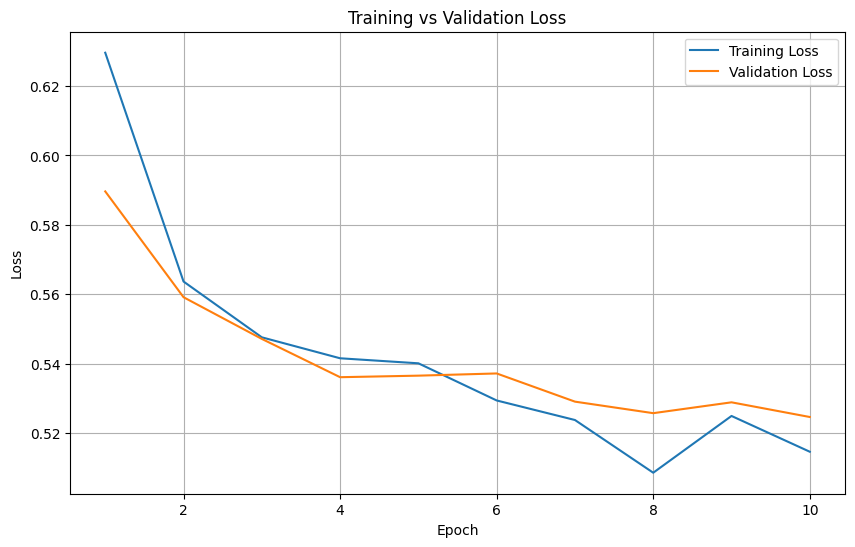

In [57]:
# TRAINING / VALIDATION LOSS
plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history["train_loss"],
    label="Training Loss"
)

plt.plot(
    epochs_range,
    history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title("Training vs Validation Loss")

plt.legend()

plt.grid(True)

plt.show()

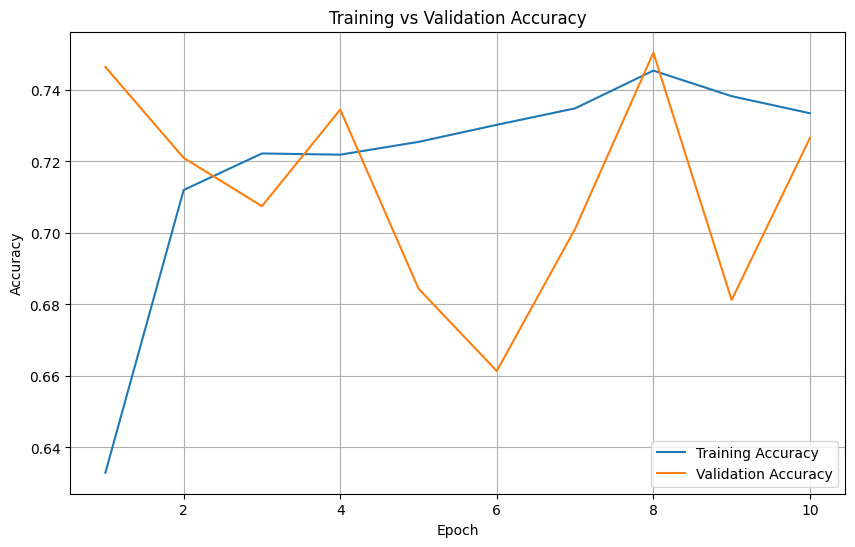

In [58]:
# TRAINING / VALIDATION ACCURACY

plt.figure(figsize=(10, 6))

plt.plot(
    epochs_range,
    history["train_accuracy"],
    label="Training Accuracy"
)

plt.plot(
    epochs_range,
    history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.title("Training vs Validation Accuracy")

plt.legend()

plt.grid(True)

plt.show()

In [59]:
# DIAGNÓSTICO AUTOMÁTICO
final_train_loss = history["train_loss"][-1]
final_val_loss = history["val_loss"][-1]

final_train_acc = history["train_accuracy"][-1]
final_val_acc = history["val_accuracy"][-1]

loss_gap = abs(final_train_loss - final_val_loss)

acc_gap = abs(final_train_acc - final_val_acc)

In [60]:
print("===================================================")
print("DIAGNÓSTICO DEL ENTRENAMIENTO")
print("===================================================")

print(f"Final Train Loss: {final_train_loss:.4f}")
print(f"Final Validation Loss: {final_val_loss:.4f}")

print(f"\nFinal Train Accuracy: {final_train_acc:.4f}")
print(f"Final Validation Accuracy: {final_val_acc:.4f}")

print(f"\nLoss Gap: {loss_gap:.4f}")
print(f"Accuracy Gap: {acc_gap:.4f}")

DIAGNÓSTICO DEL ENTRENAMIENTO
Final Train Loss: 0.5147
Final Validation Loss: 0.5247

Final Train Accuracy: 0.7335
Final Validation Accuracy: 0.7266

Loss Gap: 0.0100
Accuracy Gap: 0.0069


In [61]:
# HEURÍSTICA SIMPLE DE DIAGNÓSTICO
print("\n===================================================")
print("ANÁLISIS")
print("===================================================")

if acc_gap > 0.15 and final_train_acc > final_val_acc:

    print("⚠️ Posible OVERFITTING detectado")
    print("- El modelo aprende train mejor que validation")
    print("- Existe pérdida de generalización")

elif final_train_acc < 0.70 and final_val_acc < 0.70:

    print("⚠️ Posible UNDERFITTING detectado")
    print("- El modelo aún no aprende patrones suficientes")

else:

    print("✅ Entrenamiento relativamente estable")
    print("- No se observan señales severas de sobreajuste")


ANÁLISIS
✅ Entrenamiento relativamente estable
- No se observan señales severas de sobreajuste


# 11. Evaluación en conjunto de test

In [62]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    ConfusionMatrixDisplay
)

In [63]:
# EVALUACIÓN FINAL EN TEST SET
# MODO EVALUACIÓN
model.eval()

# ALMACENAMIENTO DE PREDICCIONES
all_labels = []
all_preds = []
all_probs = []

# ============================================================
# INFERENCIA SOBRE TEST SET
# ============================================================

with torch.no_grad():

    for images, labels in test_loader:

        # ----------------------------------------------------
        # Transferencia a dispositivo
        # ----------------------------------------------------
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        # ----------------------------------------------------
        # Forward pass
        # ----------------------------------------------------
        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        preds = torch.argmax(probs, dim=1)

        # ----------------------------------------------------
        # Guardar resultados
        # ----------------------------------------------------
        all_labels.extend(labels.cpu().numpy())

        all_preds.extend(preds.cpu().numpy())

        all_probs.extend(probs[:, 1].cpu().numpy())

# ============================================================
# CONVERSIÓN A NUMPY
# ============================================================

y_true = np.array(all_labels)

y_pred = np.array(all_preds)

y_probs = np.array(all_probs)

# ============================================================
# MÉTRICAS FINALES
# ============================================================

test_accuracy = accuracy_score(y_true, y_pred)

test_precision = precision_score(
    y_true,
    y_pred,
    zero_division=0
)

test_recall = recall_score(
    y_true,
    y_pred,
    zero_division=0
)

test_f1 = f1_score(
    y_true,
    y_pred,
    zero_division=0
)

test_auc = roc_auc_score(
    y_true,
    y_probs
)

/home/luisgm/Documents/AI Master Tecnologico de Monterrey/PI/Repo/RingGalaxiesAnalysis/.venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:1095: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [64]:
print("===================================================")
print("RESULTADOS FINALES EN TEST SET")
print("===================================================")

print(f"Accuracy : {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall   : {test_recall:.4f}")
print(f"F1-Score : {test_f1:.4f}")
print(f"ROC-AUC  : {test_auc:.4f}")

RESULTADOS FINALES EN TEST SET
Accuracy : 0.7194
Precision: 0.4046
Recall   : 0.7471
F1-Score : 0.5249
ROC-AUC  : 0.8073



CONFUSION MATRIX
[[710 287]
 [ 66 195]]


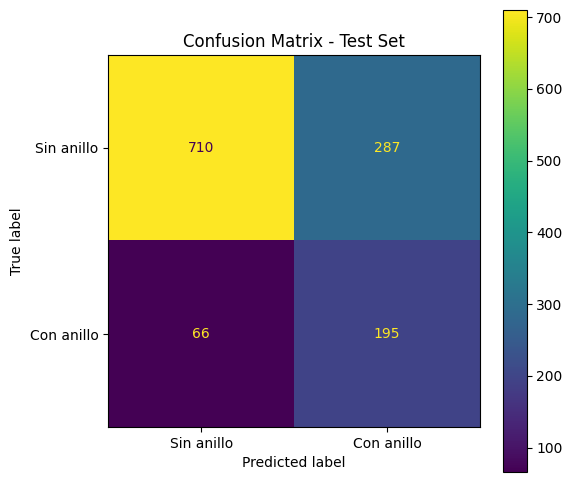

In [65]:
# MATRIZ DE CONFUSIÓN
cm = confusion_matrix(y_true, y_pred)

print("\n===================================================")
print("CONFUSION MATRIX")
print("===================================================")

print(cm)

# ============================================================
# VISUALIZACIÓN MATRIZ DE CONFUSIÓN
# ============================================================

fig, ax = plt.subplots(figsize=(6, 6))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Sin anillo",
        "Con anillo"
    ]
)

disp.plot(ax=ax)

plt.title("Confusion Matrix - Test Set")

plt.show()

In [66]:
# CLASSIFICATION REPORT
print("\n===================================================")
print("CLASSIFICATION REPORT")
print("===================================================")

print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "Sin anillo",
            "Con anillo"
        ]
    )
)


CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Sin anillo       0.91      0.71      0.80       997
  Con anillo       0.40      0.75      0.52       261

    accuracy                           0.72      1258
   macro avg       0.66      0.73      0.66      1258
weighted avg       0.81      0.72      0.74      1258



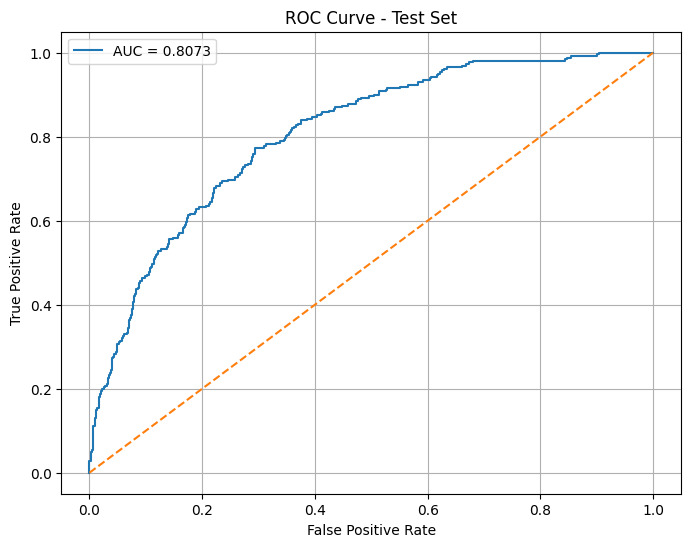

In [67]:
# CURVA ROC
fpr, tpr, thresholds = roc_curve(
    y_true,
    y_probs
)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"AUC = {test_auc:.4f}"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--"
)

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve - Test Set")

plt.legend()

plt.grid(True)

plt.show()

In [68]:
# INTERPRETACIÓN AUTOMÁTICA
print("\n===================================================")
print("INTERPRETACIÓN AUTOMÁTICA")
print("===================================================")

if test_auc >= 0.90:

    print("✅ Excelente capacidad discriminativa")

elif test_auc >= 0.80:

    print("✅ Buen desempeño discriminativo")

elif test_auc >= 0.70:

    print("⚠️ Desempeño aceptable")

else:

    print("⚠️ Capacidad discriminativa limitada")

# ------------------------------------------------------------

if test_recall < 0.60:

    print("\n⚠️ Recall bajo")
    print("- El modelo podría estar perdiendo galaxias con anillo")

else:

    print("\n✅ Sensibilidad razonable sobre clase positiva")


INTERPRETACIÓN AUTOMÁTICA
✅ Buen desempeño discriminativo

✅ Sensibilidad razonable sobre clase positiva


In [69]:
# ============================================================
# RESUMEN FINAL
# ============================================================

print("\n===================================================")
print("EVALUACIÓN FINAL COMPLETADA")
print("===================================================")

print("✅ Métricas calculadas")
print("✅ Matriz de confusión generada")
print("✅ Curva ROC construida")
print("✅ Baseline evaluado correctamente")


EVALUACIÓN FINAL COMPLETADA
✅ Métricas calculadas
✅ Matriz de confusión generada
✅ Curva ROC construida
✅ Baseline evaluado correctamente


# 12. Importancia de Características e Interpretabilidad del Modelo

## Interpretabilidad en Deep Learning para Astronomía

En problemas tradicionales de Machine Learning basados en datos tabulares, la importancia de variables suele analizarse mediante técnicas como:

- Feature Importance en Random Forests
- Permutation Importance
- SHAP Values
- Coeficientes lineales
- Métodos Filter, Wrapper y Embedded

Sin embargo, estas metodologías no son directamente aplicables en problemas de visión computacional, ya que las Redes Neuronales Convolucionales (CNNs) aprenden representaciones espaciales distribuidas y altamente no lineales.

En este proyecto, las entradas del modelo corresponden a imágenes astronómicas multibanda representadas como tensores de dimensión:

$$
(3,\ 256,\ 256)
$$

donde cada píxel participa simultáneamente en patrones geométricos y morfológicos complejos.

## Representaciones Jerárquicas en CNNs

Las CNNs construyen representaciones progresivamente más abstractas mediante convoluciones sucesivas.

### Capas iniciales

Aprenden patrones básicos de bajo nivel:

- bordes,
- gradientes,
- blobs luminosos,
- contrastes locales.

### Capas intermedias

Capturan estructuras morfológicas más complejas:

- brazos espirales,
- regiones elongadas,
- simetrías,
- barras galácticas.

### Capas profundas

Aprenden configuraciones semánticas completas:

- estructuras anulares,
- relaciones espaciales entre núcleo y disco,
- morfología global de la galaxia.

Debido a esta naturaleza jerárquica y distribuida:

- no existe una única variable interpretable,
- ni una correspondencia directa entre una “feature” y una propiedad física aislada.

Por esta razón, la interpretabilidad en CNNs requiere enfoques visuales especializados.

## Grad-CAM: Explainability Visual para CNNs

Para interpretar el comportamiento del modelo se utilizará:

### Gradient-weighted Class Activation Mapping (Grad-CAM)

Grad-CAM permite identificar qué regiones espaciales de la imagen fueron más relevantes para la predicción realizada por la red neuronal.

El método combina:

- gradientes de la clase objetivo,
- mapas de activación convolucionales,
- ponderación espacial de activaciones,

para generar mapas de calor (*heatmaps*) que resaltan las zonas más influyentes en la decisión del modelo.

### Relevancia Astronómica de Grad-CAM

En astronomía computacional, Grad-CAM resulta particularmente útil porque permite verificar si la CNN está enfocándose en estructuras físicamente plausibles, tales como:

- anillos galácticos,
- barras,
- núcleos,
- brazos espirales,
- regiones luminosas relevantes,

en lugar de aprender:

- ruido instrumental,
- artefactos de adquisición,
- bordes artificiales,
- correlaciones espurias.

### Objetivo Científico de la Interpretabilidad

El objetivo no es únicamente obtener alta precisión predictiva, sino también validar científicamente que el modelo está aprendiendo patrones astronómicos consistentes.

La interpretabilidad permite:

- aumentar la confianza científica del modelo,
- detectar sesgos instrumentales,
- identificar posibles casos de sobreajuste,
- validar coherencia morfológica,
- inspeccionar la capacidad de generalización.

### Selección de la Capa Objetivo

Grad-CAM requiere seleccionar una capa convolucional profunda del modelo.

En EfficientNet-B0 se utilizará la última capa convolucional previa al clasificador final:

```python
model.features[-1]
```

La hipotesis es que esta capa contiene representaciones semánticas de alto nivel asociadas a la morfología galáctica.

### Flujo de Interpretabilidad

El procedimiento implementado será:

* Seleccionar una galaxia del conjunto de prueba.
* Ejecutar una predicción del modelo.
* Generar el mapa Grad-CAM.
* Convertir la imagen astronómica al formato RGB visualizable.
* Superponer el heatmap sobre la galaxia original.
* Analizar visualmente las regiones activadas.

### Interpretación de Resultados

Las regiones resaltadas por Grad-CAM indican las zonas que más contribuyeron a la clasificación final del modelo.

Idealmente, el modelo debería concentrar su atención sobre:

* anillos galácticos,
* estructuras centrales,
* barras,
* patrones morfológicos relevantes.

Si las activaciones aparecen: fuera de la galaxia, en regiones vacías, en bordes artificiales, o distribuidas aleatoriamente, esto podría indicar:
* sobreajuste,
* problemas de preprocesamiento,
* insuficiente capacidad de generalización.

Etiqueta real : 1
Predicción    : 1


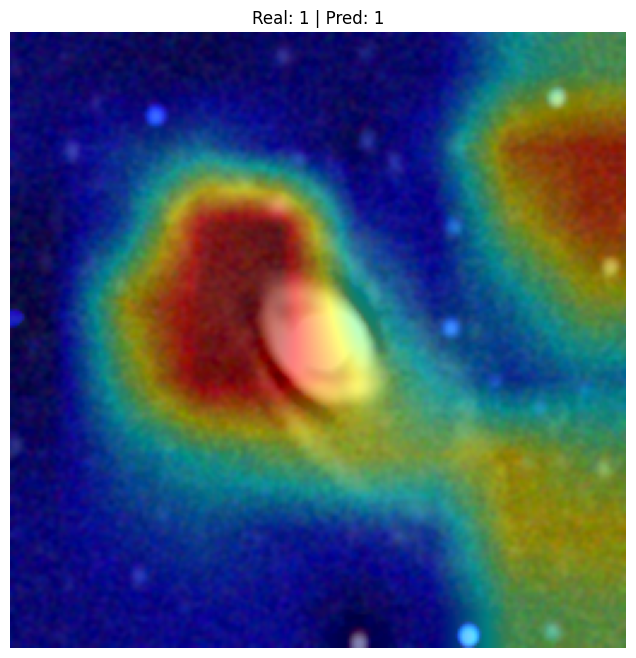

In [86]:
import torch
import numpy as np
import matplotlib.pyplot as plt

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# ==========================================
# Selección robusta de la capa objetivo
# ==========================================
if hasattr(model, "features"):
    # EfficientNet / MobileNet
    target_layer = model.features[-1]

elif hasattr(model, "layer4"):
    # ResNet
    target_layer = model.layer4[-1]

else:
    raise RuntimeError(
        "No se encontró una capa compatible para GradCAM."
    )

# ==========================================
# Preparar muestra
# ==========================================
target_label = 1

sample_tensor, sample_label = next(
    (img, lbl)
    for img, lbl in test_dataset
    if lbl == target_label
)

input_tensor = sample_tensor.unsqueeze(0).to(DEVICE)

# ==========================================
# Inferencia
# ==========================================
model.eval()
model.requires_grad_(True)

output = model(input_tensor)

prediction = torch.argmax(output, dim=1).item()

print(f"Etiqueta real : {sample_label}")
print(f"Predicción    : {prediction}")

# ==========================================
# Targets GradCAM
# ==========================================
targets = [ClassifierOutputTarget(prediction)]

# ==========================================
# GradCAM (patrón oficial)
# ==========================================
with GradCAM(
    model=model,
    target_layers=[target_layer]
) as cam:

    grayscale_cam = cam(
        input_tensor=input_tensor,
        targets=targets
    )

# Primer elemento del batch
grayscale_cam = grayscale_cam[0]

# ==========================================
# Visualización
# ==========================================
# Convertir tensor CHW -> HWC
rgb_img = sample_tensor.permute(1, 2, 0).cpu().numpy()

# Normalizar a [0,1]
rgb_img = rgb_img - rgb_img.min()
rgb_img = rgb_img / rgb_img.max()

# Superponer CAM
visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

# Mostrar resultado
plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.title(
    f"Real: {sample_label} | Pred: {prediction}"
)
plt.axis("off")
plt.show()